# Classification: Jammed or Unjammed?

## Introduction

In this notebook, we will classify each realization according to whether or not it is jammed. In the unjammed cases, we will study the polarization and size of the elongated clusters.

We start importing relevant libraries:

In [1]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from matplotlib.lines import Line2D

And define parameters:

In [2]:
cell_area = np.pi
max_step = 80_000
step = 100
delta_t = 0.05

# All the seeds
number_of_realizations=64

seed_1 = 0x87351080E25CB0FAD77A44A3BE03B491
rng_1 = np.random.default_rng(seed_1)

rng_seed = rng_1.integers(
            low=2**20, high=2**50, size=number_of_realizations
        )

## Creating and saving dataset

Create a function to calculate the final clusters statistics.

In [3]:
def calculate_final_clusters(num_cells, max_step, dens, step, rng_seed, final_fraction=0.0):
    """
    Calculates cluster statistics at the final stage of the simulation.
    Returns overall means and raw temporal averages for each individual seed.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    max_step : int
        Final time step to analyze.
    dens : float
        Cell density used in the simulation.
    step : int
        Time step interval between saved data files.
    rng_seed : list of int
        List of random seeds corresponding to different simulation runs.
    final_fraction : float, optional
        Fraction of final time steps to average over (e.g., 0.1 for last 10%).

    Returns
    -------
    dict
        Dictionary containing means, std devs, and 'seeds_data' for per-seed analysis.
    """
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"

    # Determine the last valid step available across all seeds
    stop = False
    for tic in range(100, max_step + step, step):
        for seed in rng_seed:
            dat_actual = (
                f"data/{num_cells_folder}/{dens_folder}/dat_clusters/max_number/"
                f"clusters_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_"
                f"rng_seed={seed}_step={tic:05}.dat"
            )
            if not os.path.exists(dat_actual):
                stop = True
                break
        if stop:
            last_step = tic - step
            break
    else:
        last_step = max_step

    print(f"Last step found: {last_step} for density: {dens}")

    # Define the window of time steps to average
    all_steps = list(range(100, last_step + step, step))
    if final_fraction > 0:
        n_final = max(1, int(len(all_steps) * final_fraction))
        steps_to_use = all_steps[-n_final:]
    else:
        steps_to_use = [last_step]

    # Initialize lists to store temporal averages per seed
    # Label 1 lists
    s_max_round, s_2max_round, n_round, s_ratio_round = [], [], [], []
    s_max_elong, s_2max_elong, n_elong, s_ratio_elong = [], [], [], []
    
    # Label 2 lists
    s_max_round_2, s_2max_round_2, n_round_2, s_ratio_round_2 = [], [], [], []
    s_max_elong_2, s_2max_elong_2, n_elong_2, s_ratio_elong_2 = [], [], [], []

    for seed in rng_seed:
        dfs = []
        for s in steps_to_use:
            dat_path = (
                f"data/{num_cells_folder}/{dens_folder}/dat_clusters/max_number/"
                f"clusters_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_"
                f"rng_seed={seed}_step={s:05}.dat"
            )
            if os.path.exists(dat_path):
                dfs.append(pd.read_csv(dat_path))

        if not dfs:
            continue

        df_seed = pd.concat(dfs, ignore_index=True)
        
        # Temporal averaging for Label 1
        s_max_round.append(df_seed["max_round"].mean())
        s_2max_round.append(df_seed["2_max_round"].mean())
        n_round.append(df_seed["n_round"].mean())
        s_ratio_round.append((df_seed["2_max_round"] / df_seed["max_round"].replace(0, np.nan)).mean())
        
        s_max_elong.append(df_seed["max_elongated"].mean())
        s_2max_elong.append(df_seed["2_max_elongated"].mean())
        n_elong.append(df_seed["n_elongated"].mean())
        s_ratio_elong.append((df_seed["2_max_elongated"] / df_seed["max_elongated"].replace(0, np.nan)).mean())

        # Temporal averaging for Label 2
        s_max_round_2.append(df_seed["max_round_2"].mean())
        s_2max_round_2.append(df_seed["2_max_round_2"].mean())
        n_round_2.append(df_seed["n_round_2"].mean())
        s_ratio_round_2.append((df_seed["2_max_round_2"] / df_seed["max_round_2"].replace(0, np.nan)).mean())
        
        s_max_elong_2.append(df_seed["max_elongated_2"].mean())
        s_2max_elong_2.append(df_seed["2_max_elongated_2"].mean())
        n_elong_2.append(df_seed["n_elongated_2"].mean())
        s_ratio_elong_2.append((df_seed["2_max_elongated_2"] / df_seed["max_elongated_2"].replace(0, np.nan)).mean())

    return {
        "mean": {
            "MAX_round": np.mean(s_max_round), "2_MAX_round": np.mean(s_2max_round), "N_round": np.mean(n_round),
            "MAX_elongated": np.mean(s_max_elong), "MAX_round_2": np.mean(s_max_round_2),
            "ratio_s_round": np.mean(s_ratio_round), "ratio_s_round_2": np.mean(s_ratio_round_2)
        },
        "seeds_data": {
            "s_max_round": s_max_round, "s_max_round_2": s_max_round_2,
            "n_round": n_round, "n_round_2": n_round_2,
            "ratio_round": s_ratio_round, "ratio_round_2": s_ratio_round_2
        },
        "last_step": last_step
    }

And another function to calculate the final phenotype statistics:

In [4]:
def calculate_final_phenotype(num_cells, max_step, dens, step, rng_seed, final_fraction=0.0):
    """
    Calculates phenotype statistics averaging over the final fraction of steps.
    Returns per-seed temporal averages.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    max_step : int
        Final time step to analyze.
    dens : float
        Cell density used in the simulation.
    step : int
        Time step interval between saved data files.
    rng_seed : list of int
        List of random seeds for ensemble averaging.
    final_fraction : float, optional
        Fraction of the total trajectory to average (e.g., 0.1).

    Returns
    -------
    dict
        Dictionary with ensemble means and 'seeds_data' for individual realization analysis.
    """
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"
    
    stop = False
    for tic in range(100, max_step + step, step):
        for seed in rng_seed:
            dat_actual = (
                f"data/{num_cells_folder}/{dens_folder}/dat_phenotype/"
                f"phenotype_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_"
                f"With_Shrinking_rng_seed={seed}_step={tic:05}.dat"
            )
            if not os.path.exists(dat_actual):
                stop = True
                break
        if stop:
            last_step = tic - step
            break
    else:
        last_step = max_step
    
    print(f"Last step found: {last_step} for density: {dens}")
    
    all_steps = list(range(100, last_step + step, step))
    if final_fraction > 0:
        n_final = max(1, int(len(all_steps) * final_fraction))
        steps_to_use = all_steps[-n_final:]
    else:
        steps_to_use = [last_step]

    # Initialize lists for per-seed results
    seeds_f_elongated, seeds_f_round, seeds_f_binary, seeds_aspect_ratio = [], [], [], []

    for seed in rng_seed:
        dfs = []
        for s in steps_to_use:
            dat_path = (
                f"data/{num_cells_folder}/{dens_folder}/dat_phenotype/"
                f"phenotype_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_"
                f"With_Shrinking_rng_seed={seed}_step={s:05}.dat"
            )
            if os.path.exists(dat_path):
                dfs.append(pd.read_csv(dat_path))
        
        if not dfs:
            continue
        
        df_seed = pd.concat(dfs, ignore_index=True)
        
        # Temporal means for this specific seed
        seeds_f_elongated.append(df_seed["fraction_elongated"].mean())
        seeds_f_round.append(df_seed["fraction_round"].mean())
        seeds_f_binary.append(df_seed["fraction_binary"].mean())
        seeds_aspect_ratio.append(df_seed["mean_aspect_ratio"].mean())

    return {
        "mean": {
            "mean_aspect_ratio": np.mean(seeds_aspect_ratio),
            "fraction_elongated": np.mean(seeds_f_elongated),
            "fraction_round": np.mean(seeds_f_round),
            "fraction_binary": np.mean(seeds_f_binary),
        },
        "seeds_data": {
            "f_elongated": seeds_f_elongated,
            "f_round": seeds_f_round,
            "f_binary": seeds_f_binary,
            "aspect_ratio": seeds_aspect_ratio
        }
    }

And now we use these functions to collect the data:

In [ ]:
# Choose the number of cells and densities
Ns = [1000, 2000, 3000, 5000, 10000]

densities_dict = {

    10000: [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.855, 0.858,
            0.86, 0.862, 0.865, 0.87, 0.88, 0.9],

    5000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.845, 0.85,
            0.855, 0.86, 0.87, 0.88, 0.9],

    3000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.85,
            0.86, 0.87, 0.88, 0.9],

    2000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.845, 0.848,
            0.85, 0.852, 0.855, 0.86, 0.87, 0.88, 0.9],

    1000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.845, 0.848,
            0.85, 0.852, 0.855, 0.86, 0.87, 0.88, 0.9],
}

# Create lists to store data
X_all = []
rho_labels = []
N_labels = []

# Read every N and rho
for N in Ns:
    for rho in densities_dict[N]:
        # Calculate the final clusters
        cluster_data = calculate_final_clusters(
            N, max_step, rho, step, rng_seed, final_fraction=0.1
        )
        # Calculate the final phenotypes
        pheno_data = calculate_final_phenotype(
            N, max_step, rho, step, rng_seed, final_fraction=0.1
        )
        # Take the data
        s_max_norm = np.array(cluster_data["seeds_data"]["s_max_round"]) / N
        s_max_norm_2 = np.array(cluster_data["seeds_data"]["s_max_round_2"]) / N
        f_elongated = np.array(pheno_data["seeds_data"]["f_elongated"])
        # Add them to the lists
        for fe, s, s_2 in zip(f_elongated, s_max_norm, s_max_norm_2):
            X_all.append([fe, s, s_2])
            rho_labels.append(rho)
            N_labels.append(N)

X_all = np.array(X_all)
rho_labels = np.array(rho_labels)
N_labels = np.array(N_labels)

# Take every important feature
f_all = X_all[:, 0]
s_all = X_all[:, 1]
s_2_all = X_all[:, 2]

# Save everything in a csv
df = pd.DataFrame({
    "N": N_labels,
    "rho": rho_labels,
    "f_elongated": f_all,
    "s_max_norm": s_all,
    "s_max_norm_2": s_2_all
})

folder_path = "data/processed/jamming"
os.makedirs(folder_path, exist_ok=True)

df.to_csv(f"{folder_path}/final_dataset.csv", index=False)

Last step found: 70000 for density: 0.4
Last step found: 70000 for density: 0.4
Last step found: 70000 for density: 0.5
Last step found: 70000 for density: 0.5
Last step found: 70000 for density: 0.6
Last step found: 70000 for density: 0.6
Last step found: 70000 for density: 0.7
Last step found: 70000 for density: 0.7
Last step found: 70000 for density: 0.75
Last step found: 70000 for density: 0.75
Last step found: 70000 for density: 0.76
Last step found: 70000 for density: 0.76
Last step found: 70000 for density: 0.77
Last step found: 70000 for density: 0.77
Last step found: 70000 for density: 0.78
Last step found: 70000 for density: 0.78
Last step found: 70000 for density: 0.79
Last step found: 70000 for density: 0.79
Last step found: 70000 for density: 0.8
Last step found: 70000 for density: 0.8
Last step found: 70000 for density: 0.81
Last step found: 70000 for density: 0.81
Last step found: 70000 for density: 0.82
Last step found: 70000 for density: 0.82
Last step found: 70000 for

## Reading dataset

We read the dataset previously created

In [3]:
# Read
df = pd.read_csv("data/processed/jamming/final_dataset.csv")

# Take the useful features
N_labels = df["N"].values
rho_labels = df["rho"].values
f_all = df["f_elongated"].values
s_all = df["s_max_norm"].values
s_2_all = df["s_max_norm_2"].values

## Global phase space

Now we are going to plot different graphs to see if we can classificate if a realization is jammed or unjammed.

We can study the size of the largest cluster of round cells (for both labels 1 and 2) and the fraction of elongated cells.

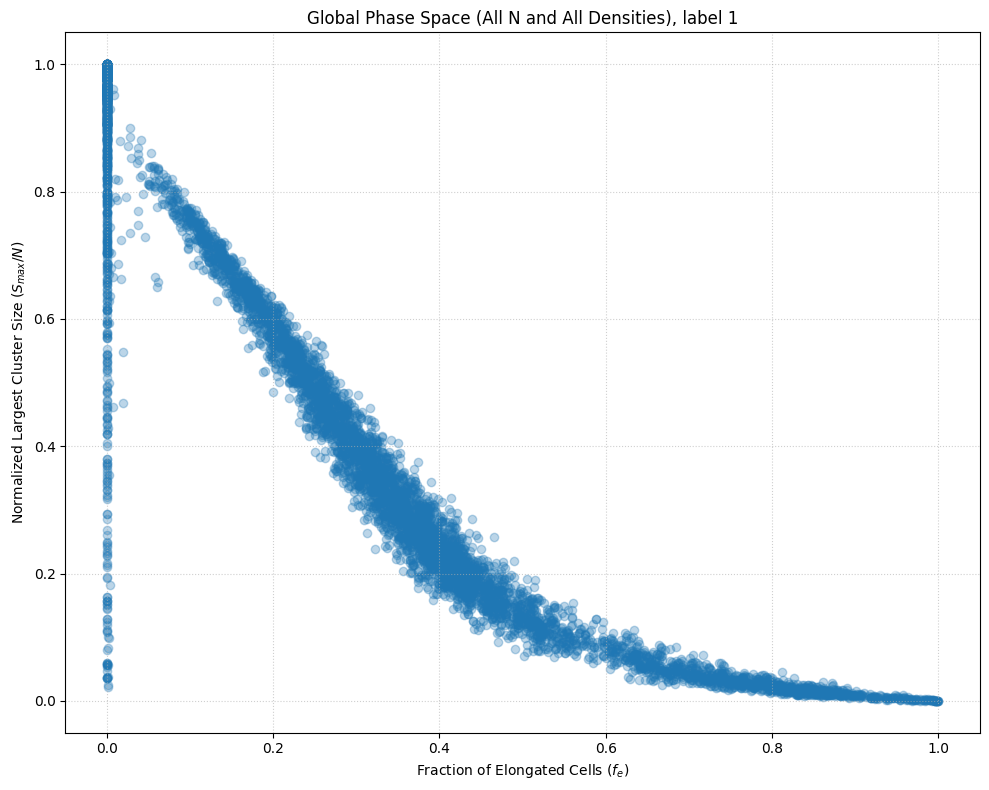

In [4]:
# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(f_all, s_all, alpha=0.3)

# Configuration
ax.set_xlabel("Fraction of Elongated Cells ($f_e$)")
ax.set_ylabel("Normalized Largest Cluster Size ($S_{max}/N$)")
ax.set_title("Global Phase Space (All N and All Densities), label 1")
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure
folder_path = "graphs/jamming"
os.makedirs(folder_path, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{folder_path}/global_phase_space_label_1.png", dpi=600)

plt.show()

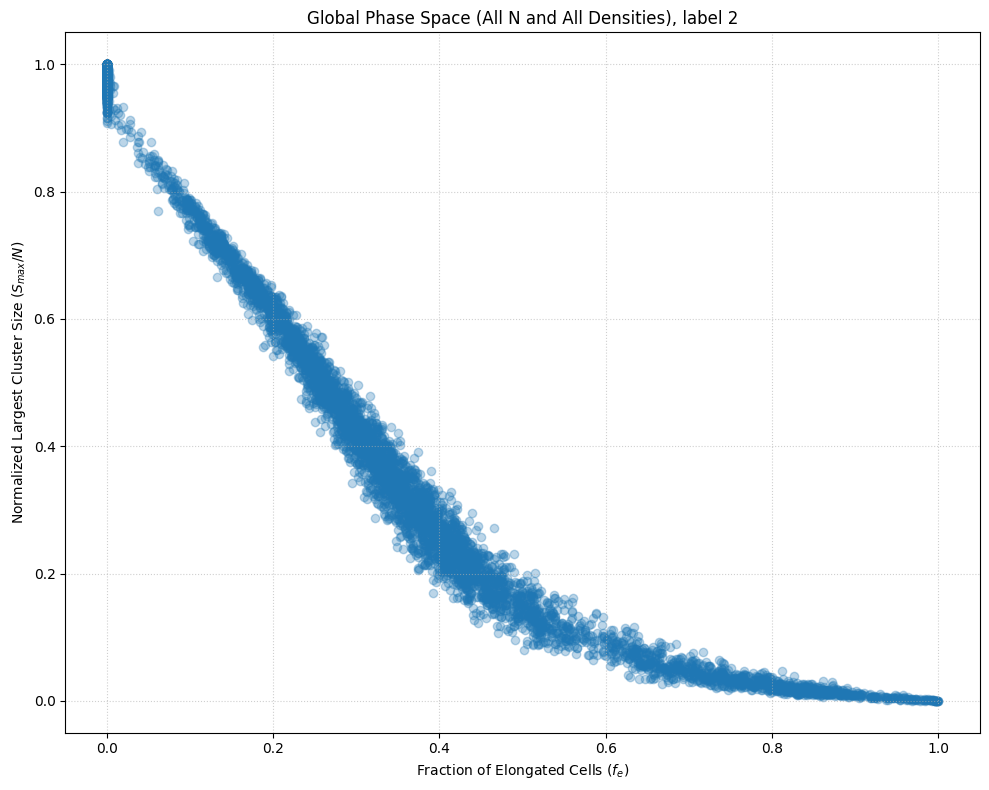

In [5]:
# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(f_all, s_2_all, alpha=0.3)

# Configuration
ax.set_xlabel("Fraction of Elongated Cells ($f_e$)")
ax.set_ylabel("Normalized Largest Cluster Size ($S_{max}/N$)")
ax.set_title("Global Phase Space (All N and All Densities), label 2")
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure
folder_path = "graphs/jamming"
os.makedirs(folder_path, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{folder_path}/global_phase_space_label_2.png", dpi=600)

plt.show()

Here we can see that for label 1 there are a lot of points that lie in the zone wit $f_e \approx 0$ and a lot of different values of $s$. This is not what we expected because when $f_e \approx 0$, all the cells are round and we should see $s \approx 1$. Because of this, we can use label 2.

We can also see the distribution of fraction of elongated cells.

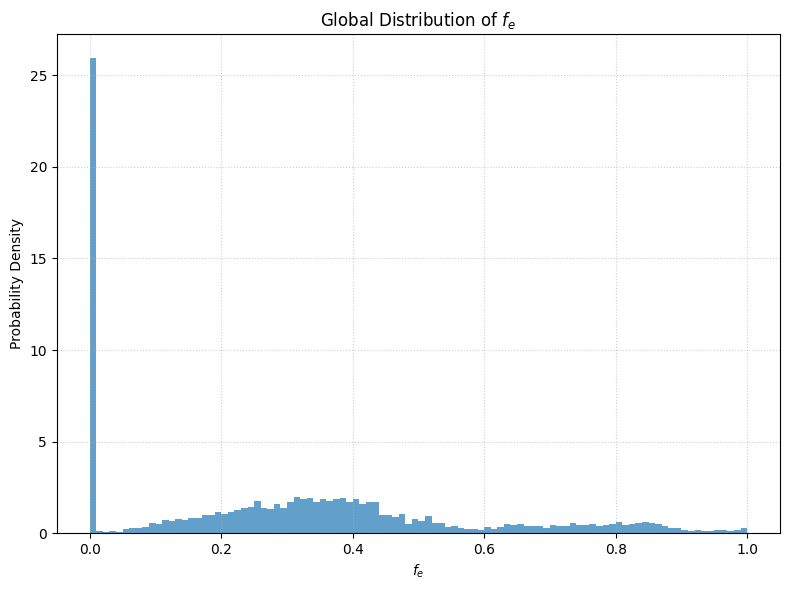

In [8]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
counts, bins, _ = ax.hist(f_all, bins=100, density=True, alpha=0.7)

# Configuration
ax.set_xlabel("$f_e$")
ax.set_ylabel("Probability Density")
ax.set_title("Global Distribution of $f_e$")
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure
folder_path = "graphs/jamming"
os.makedirs(folder_path, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{folder_path}/global_distribution_f_e.png", dpi=600)

plt.show()

## DBSCAN

We are going to apply DBSCAN in order to see if we can differentiate 2 clusters.

eps = 0.030
Clusters encontrados: 7
Puntos marcados como ruido: 815


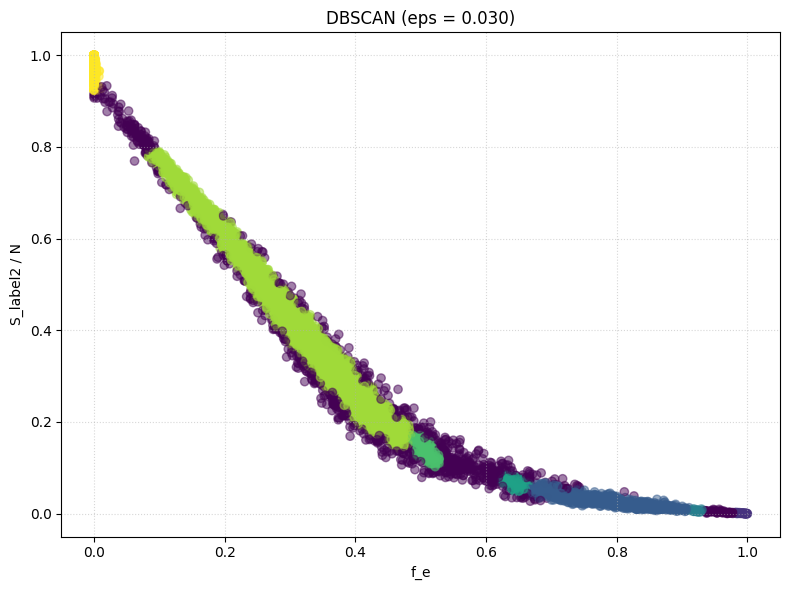

eps = 0.040
Clusters encontrados: 3
Puntos marcados como ruido: 216


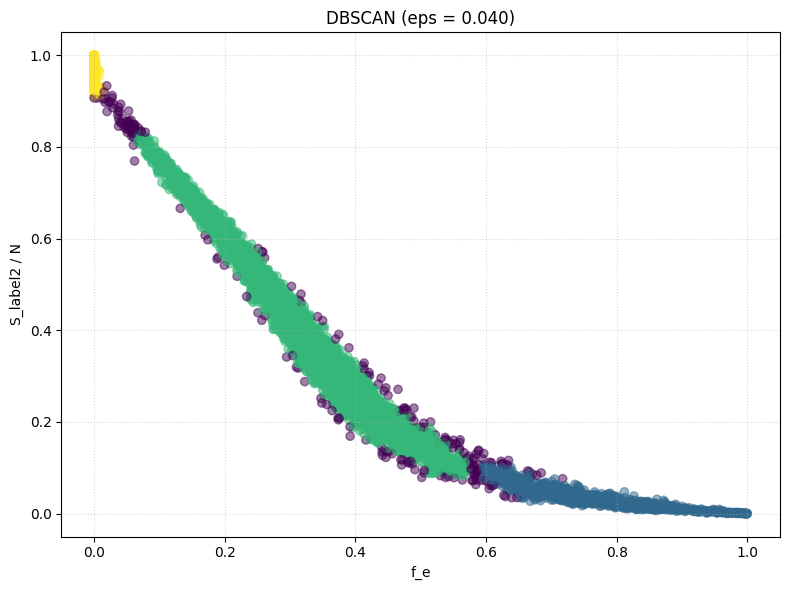

eps = 0.050
Clusters encontrados: 2
Puntos marcados como ruido: 67


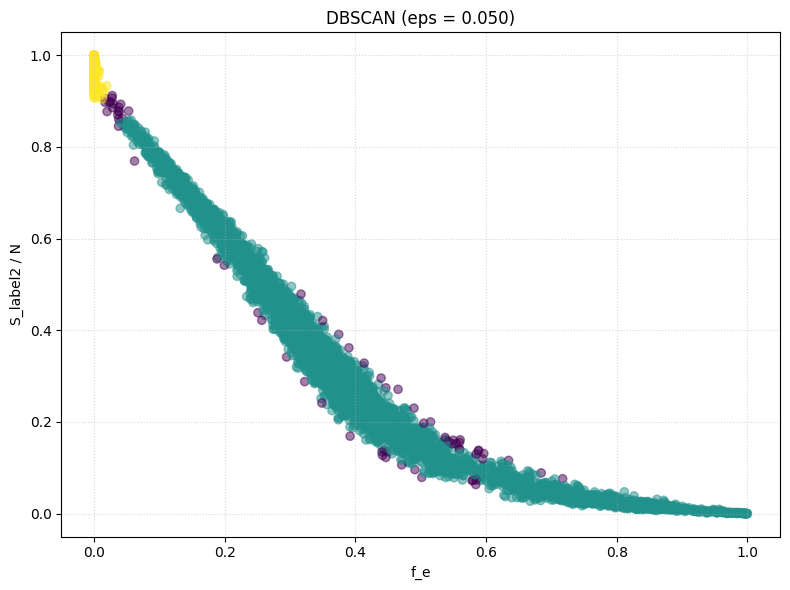

eps = 0.060
Clusters encontrados: 2
Puntos marcados como ruido: 23


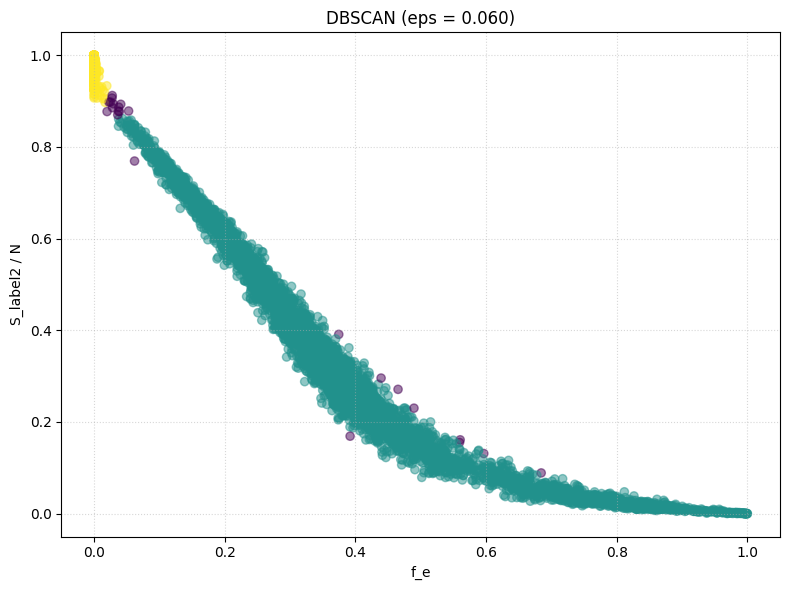

eps = 0.070
Clusters encontrados: 2
Puntos marcados como ruido: 10


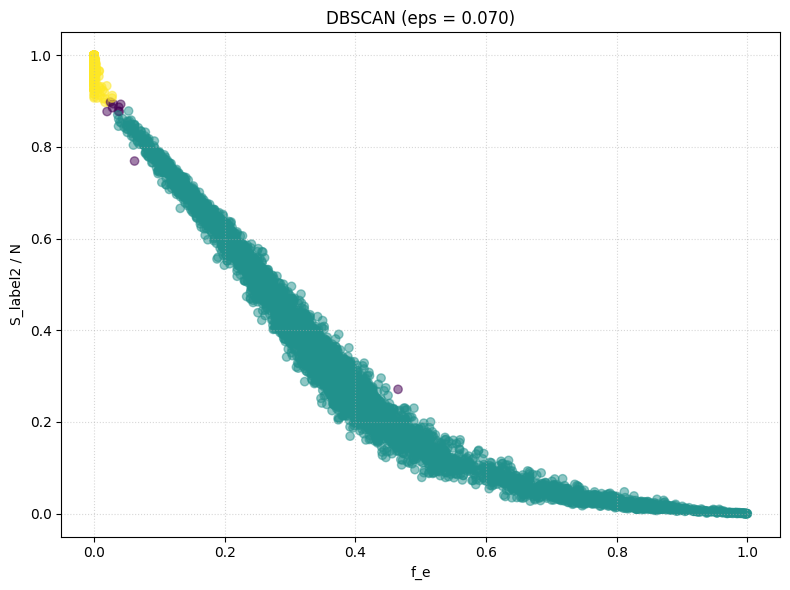

eps = 0.080
Clusters encontrados: 2
Puntos marcados como ruido: 3


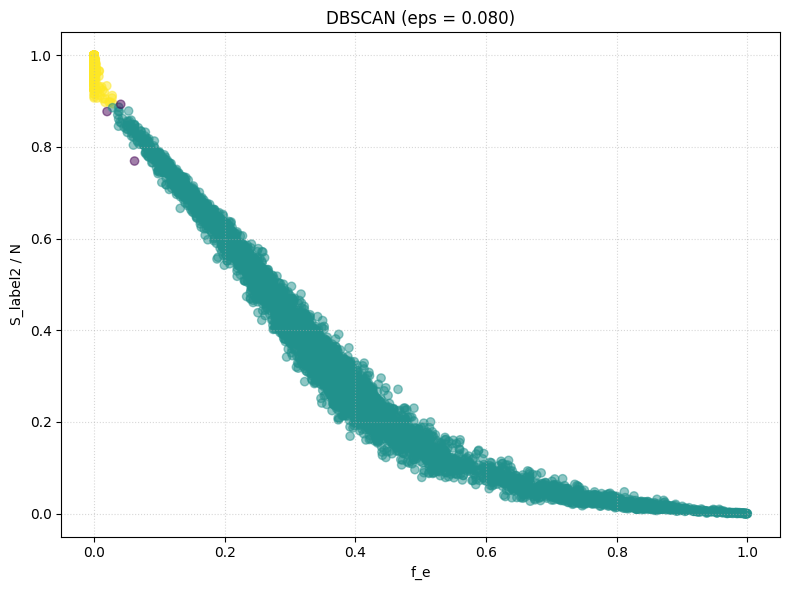

eps = 0.090
Clusters encontrados: 2
Puntos marcados como ruido: 0


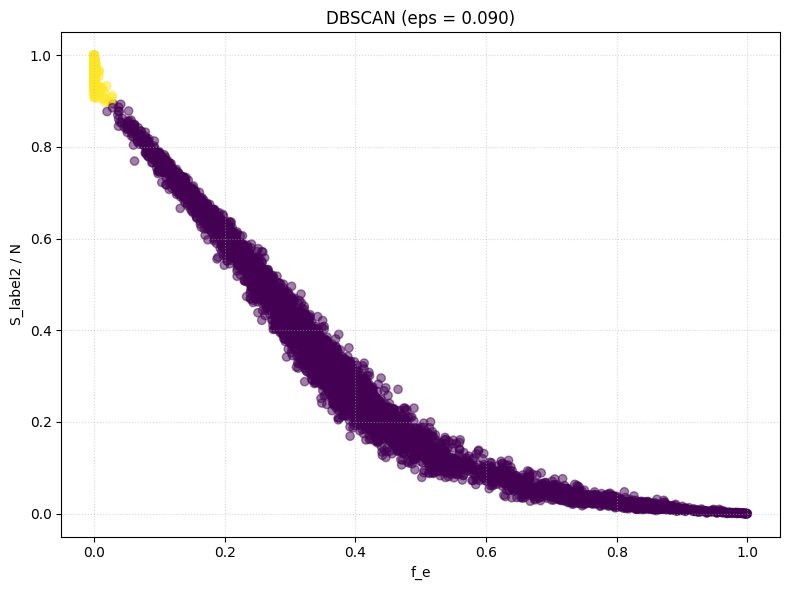

eps = 0.100
Clusters encontrados: 1
Puntos marcados como ruido: 0


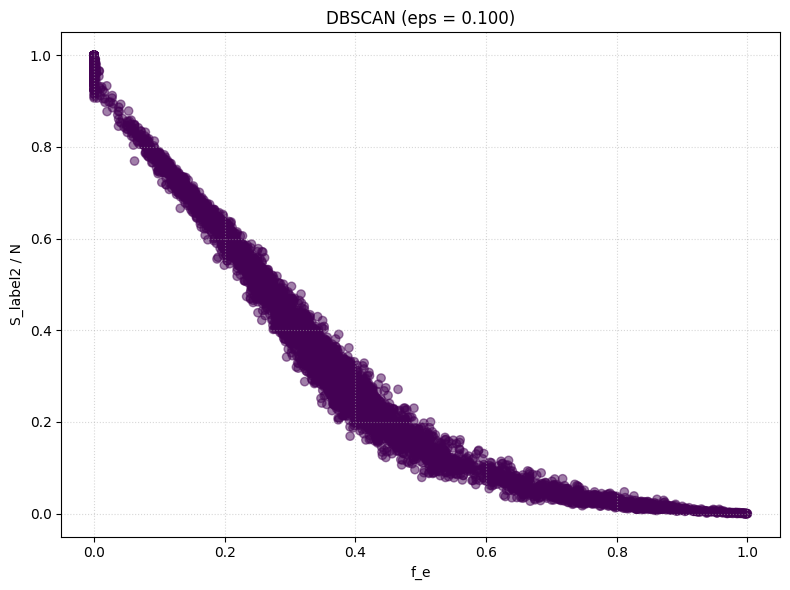

eps = 0.200
Clusters encontrados: 1
Puntos marcados como ruido: 0


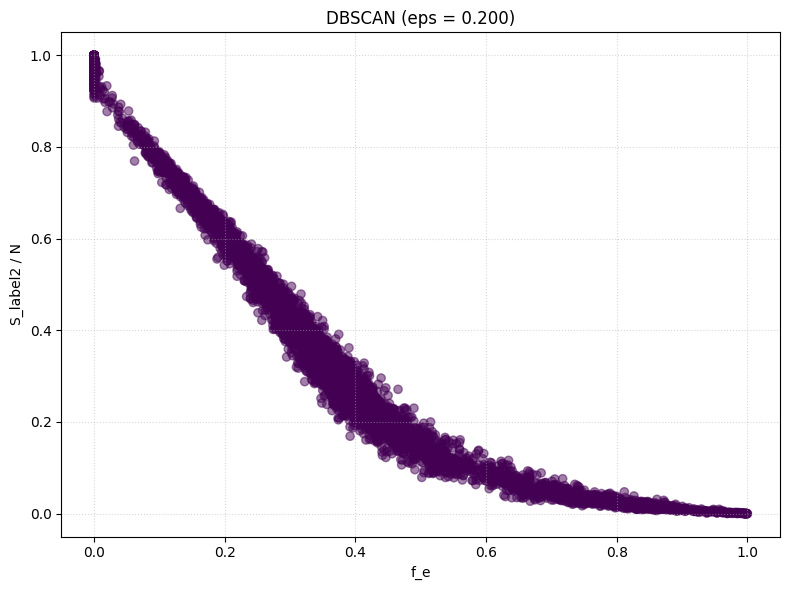

eps = 0.500
Clusters encontrados: 1
Puntos marcados como ruido: 0


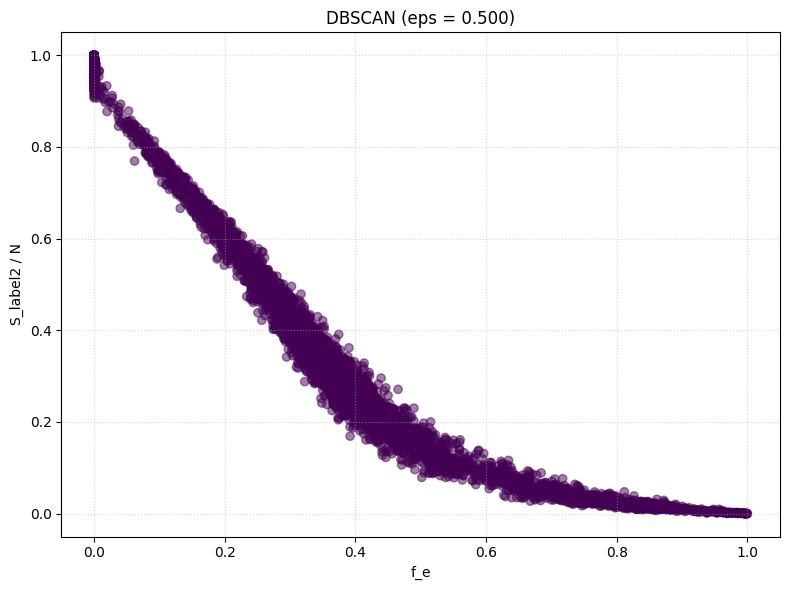

eps = 1.000
Clusters encontrados: 1
Puntos marcados como ruido: 0


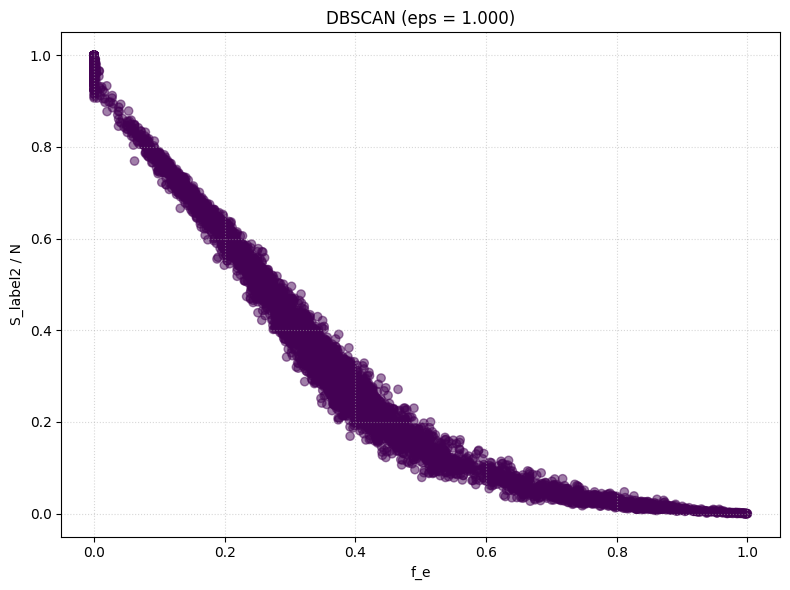

In [7]:
# Use f_e and s_label2
X = np.column_stack((f_all, s_2_all))

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create folder to save the figures
folder_path = "graphs/jamming/dbscan_sweep"
os.makedirs(folder_path, exist_ok=True)

# Values of epsilon
eps_values = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.5, 1.0]

# Bucle for eps
for eps in eps_values:
    
    # Define DBSCAN, fit and predict
    db = DBSCAN(eps=eps, min_samples=20)
    labels = db.fit_predict(X_scaled)

    # Take the number of clusters and noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps = {eps:.3f}")
    print("Clusters encontrados:", n_clusters)
    print("Puntos marcados como ruido:", n_noise)

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", alpha=0.5)

    plt.xlabel("f_e")
    plt.ylabel("S_label2 / N")
    plt.title(f"DBSCAN (eps = {eps:.3f})")
    plt.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{folder_path}/DBSCAN_eps_{eps:.3f}.png", dpi=600)
    plt.show()
    plt.close()

## Classification

To distinguish between Jammed and Unjammed realizations, we will use the results given by the DBSCAN analysis. After a sweep of the epsilon parameter, we choose $\epsilon = 0.05$. This value represents the first instance where the algorithm successfully resolves the system into two distinct clusters, capturing the inherent bimodality of the transition.

To refine the classification and handle some of the points marked as noise by the algorithm, we follow a criterion based on the phenotypes. The global distribution of the fraction of elongated cells  reveals a clear probability valley between 0.0 and approximately 0.05. While the physical gap suggests a lower threshold, we adopted a more conservative limit of $ f_e > 0.1 $ and we say that every realization that fulfill this condition is classified as unjammed. 

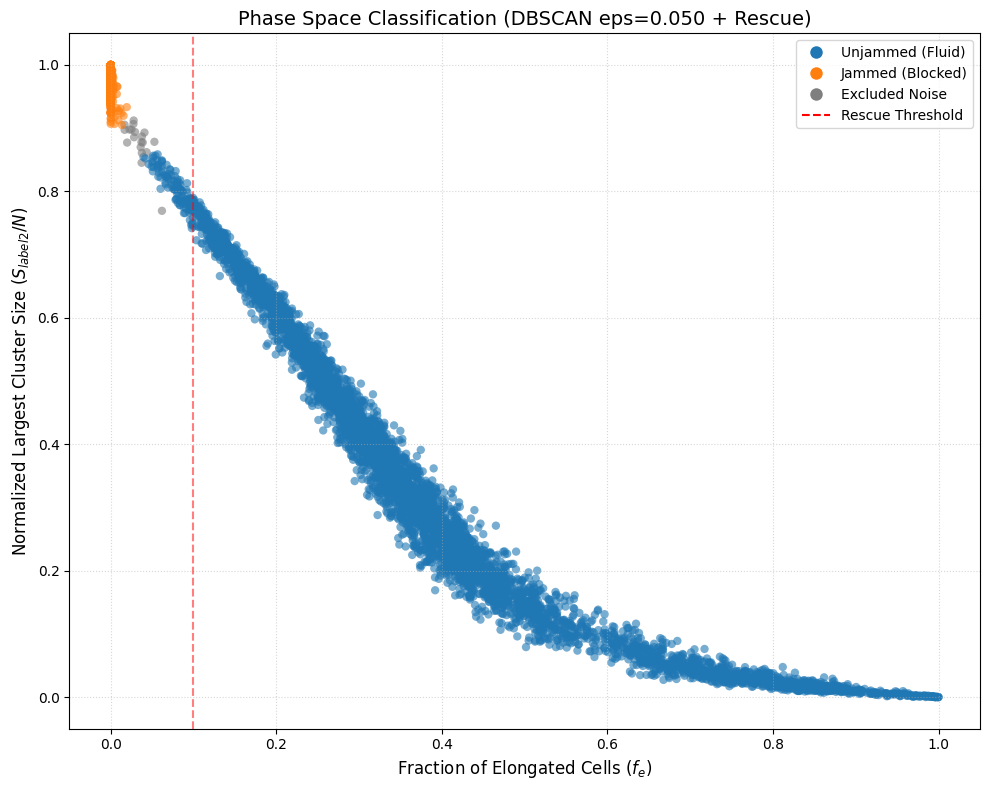

Summary of Classification:
Total points: 6976
Unjammed (Fluid): 5142
Jammed (Blocked): 1815
Excluded Noise: 19


In [4]:
# Get the data
X = np.column_stack((f_all, s_2_all))

# Define the scaler and scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Execute final DBSCAN
final_eps = 0.05
min_samples = 20

db = DBSCAN(eps=final_eps, min_samples=min_samples)
# Define the initial labels given bby DBSCAN
initial_labels = db.fit_predict(X_scaled)

# Identify original clusters
unique_labels = set(initial_labels)
if -1 in unique_labels:
    unique_labels.remove(-1)

# Define unjammed as the one that has less value of s_r
cluster_means = {l: np.mean(X[initial_labels == l, 1]) for l in unique_labels}
unjammed_label = min(cluster_means, key=cluster_means.get)
jammed_label = max(cluster_means, key=cluster_means.get)

# Create a copy of the labels
final_labels = initial_labels.copy()

# Define labels
LABEL_UNJAMMED = 0
LABEL_JAMMED = 1
LABEL_EXCLUDED_NOISE = 2

# Map clusters with the clusters
final_labels[initial_labels == unjammed_label] = LABEL_UNJAMMED
final_labels[initial_labels == jammed_label] = LABEL_JAMMED

# Rescue of noise
rescue_threshold = 0.1
mask_noise = (initial_labels == -1)

mask_rescue = mask_noise & (X[:, 0] > rescue_threshold)
final_labels[mask_rescue] = LABEL_UNJAMMED

# Noise not rescued is excluded or just defined as noise
mask_exclude = mask_noise & (~mask_rescue)
final_labels[mask_exclude] = LABEL_EXCLUDED_NOISE

# Define colors for each phase
colors = {LABEL_UNJAMMED: '#1f77b4',
          LABEL_JAMMED: '#ff7f0e',
          LABEL_EXCLUDED_NOISE: '#7f7f7f'}

color_labels = [colors[l] for l in final_labels]

# Plot
plt.figure(figsize=(10, 8))

# Scatter of the points
plt.scatter(X[:, 0], X[:, 1], c=color_labels, alpha=0.6, edgecolors='none')

# Plot the line of rescue
plt.axvline(rescue_threshold, color='r', linestyle='--', alpha=0.5, label=f'Rescue Threshold ({rescue_threshold})')

plt.xlabel("Fraction of Elongated Cells ($f_e$)", fontsize=12)
plt.ylabel("Normalized Largest Cluster Size ($S_{label2}/N$)", fontsize=12)
plt.title(f"Phase Space Classification (DBSCAN eps={final_eps:.3f} + Rescue)", fontsize=14)

# Legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Unjammed (Fluid)',
                          markerfacecolor=colors[LABEL_UNJAMMED], markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Jammed (Blocked)',
                          markerfacecolor=colors[LABEL_JAMMED], markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Excluded Noise',
                          markerfacecolor=colors[LABEL_EXCLUDED_NOISE], markersize=10),
                   Line2D([0], [0], color='r', linestyle='--', label='Rescue Threshold')]
plt.legend(handles=legend_elements, loc='best')

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

# Save the plot
graph_folder = "graphs/jamming/classification"
os.makedirs(graph_folder, exist_ok=True)
plt.savefig(f"{graph_folder}/Classified_Scatter_eps_{final_eps:.3f}.png", dpi=600)

plt.show()
plt.close()

# Summary
print("Summary of Classification:")
print(f"Total points: {len(final_labels)}")
print(f"Unjammed (Fluid): {np.sum(final_labels == LABEL_UNJAMMED)}")
print(f"Jammed (Blocked): {np.sum(final_labels == LABEL_JAMMED)}")
print(f"Excluded Noise: {np.sum(final_labels == LABEL_EXCLUDED_NOISE)}")